# Análisis exploratorio de datos

## Importaciones de librerías y bases de datos

In [1]:
# Liberías
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

df_companies = pd.read_csv('/datasets/project_sql_result_01.csv')
df_neighborhoods = pd.read_csv('/datasets/project_sql_result_04.csv')

## Estudio de los datos

In [2]:
df_companies.head()
df_neighborhoods.head()

,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000


In [3]:
df_companies.info()
df_neighborhoods.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB


## Identificamos los 10 principales barrios

In [4]:
top_10_neighborhoods = (
    df_neighborhoods.sort_values(by='average_trips').head(10)
)

top_10_neighborhoods

,dropoff_location_name,average_trips
93,Riverdale,1.800000
92,East Side,1.961538
91,Burnside,2.333333
90,Hegewisch,3.117647
89,Mount Greenwood,3.137931
88,Undef,3.800000
87,Pullman,3.896552
86,West Elsdon,5.666667
85,Montclare,5.766667
84,West Pullman,6.466667


## Gráficos

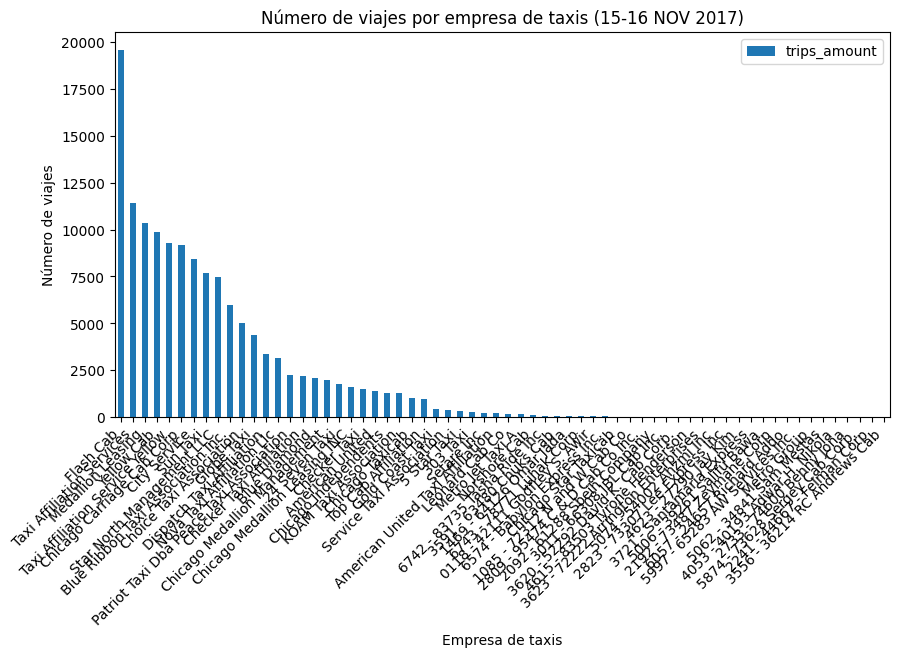

In [5]:
# Empresas de taxi y número de viejaes
df_companies.plot(
    x='company_name',
    y='trips_amount',
    kind='bar',
    figsize=(10,5)
)

plt.title('Número de viajes por empresa de taxis (15-16 NOV 2017)')
plt.xlabel('Empresa de taxis')
plt.ylabel('Número de viajes')
plt.xticks(rotation=45,ha='right')
plt.show()

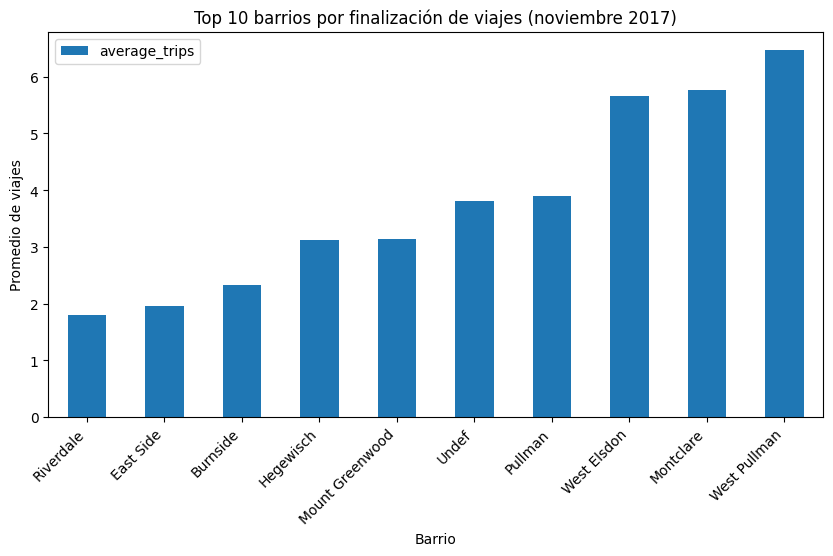

In [6]:
# Top 10 barrios por número de viajes completados

top_10_neighborhoods.plot(
    x='dropoff_location_name',
    y='average_trips',
    kind='bar',
    figsize=(10, 5)
)

plt.title('Top 10 barrios por finalización de viajes (noviembre 2017)')
plt.xlabel('Barrio')
plt.ylabel('Promedio de viajes')
plt.xticks(rotation=45, ha='right')
plt.show()

## Conclusiones del análisis exploratorio
### Gráfico 1: Empresas de taxis

* Flash Cab y Taxi Affiliation Services dominan el mercado.
* La mayoría de las empresas tienen una participación significativamente menor.
* El mercado está altamente concentrado, lo que representa una oportunidad para Zuber.

### Gráfico 2: Barrios de finalización

* Los viajes se concentran en zonas específicas, principalmente áreas céntricas y de alto tránsito.
* La demanda no está distribuida uniformemente en la ciudad.
* Identificar estos barrios es clave para optimizar la disponibilidad de vehículos.

# Prueba de Hipótesis

### Hipótesis planteadas

**Hipótesis nula (H₀):**
La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare no cambia los sábados lluviosos.

**Hipótesis alternativa (H₁):**
La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare sí cambia los sábados lluviosos.

### Nivel de significacion
α = 0.05


## Prueba estadística

In [7]:
df_weather = pd.read_csv('/datasets/project_sql_result_07.csv')

bad_weather = df_weather[
    df_weather['weather_conditions'] == 'Bad'
]['duration_seconds']

good_weather = df_weather[
    df_weather['weather_conditions'] == 'Good'
]['duration_seconds']

t_stat, p_value = stats.ttest_ind(
    bad_weather,
    good_weather,
    equal_var=False
)

p_value

6.738994326108734e-12

### Criterio de decisión

* Si p-value < α → se rechaza H₀
* Si p-value ≥ α → no se rechaza H₀


### Explicación del método usado

Se utilizó una prueba t de Student para dos muestras independientes.
Las muestras son independientes (viajes con buen clima vs mal clima).

No se asume igualdad de varianzas (equal_var=False).

Esta prueba es adecuada para comparar medias entre dos grupos.

## Conclusión de la prueba de hipótesis


El valor obtenido de p-value = 6.74 × 10⁻¹² es extremadamente menor que el nivel de significación establecido (α = 0.05).

Debido a que:

p-value ≪ α

se rechaza la hipótesis nula (H₀).

Esto indica que existe evidencia estadística muy fuerte para afirmar que la duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare cambia durante los sábados lluviosos en comparación con los sábados con buenas condiciones climáticas.

Un p-value tan pequeño implica que la probabilidad de observar una diferencia tan grande (o mayor) en la duración promedio de los viajes si realmente no hubiera diferencia entre los grupos es prácticamente nula.
  
Por lo tanto, la diferencia observada en las duraciones no se debe al azar, sino que está asociada a las condiciones climáticas adversas (lluvia o tormenta).

### Implicaciones para el negocio (Zuber)

El clima es un factor externo relevante que afecta el tiempo de los viajes.

En días lluviosos, Zuber podría:

* Ajustar estimaciones de tiempo de llegada (ETA).
* Optimizar precios dinámicos.
* Incrementar la disponibilidad de vehículos para mitigar retrasos.

Incorporar variables climáticas en los modelos de predicción puede mejorar la experiencia del usuario y la eficiencia operativa.


## Criterios finales

Con un nivel de confianza superior al 99.99%, se concluye que las condiciones climáticas lluviosas influyen significativamente en la duración de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare los sábados.